# YOLOv11m vs YOLOv12m — Fair Medium-Class Comparison

**Dissertation Phase 5 · Model Selection Evaluation**

Both models trained on the **same merged 2-class dataset** under **identical conditions**:

| Setting | Value |
|---------|-------|
| Dataset | Merged 2-class (cigarette + cigarette_like_object) |
| Train images | 3,478 · Valid images: 946 |
| Image size | 640 x 640 px |
| Hardware | NVIDIA L4 (Google Colab Pro) |
| Optimizer | AdamW · lr0=0.001 · cos_lr |
| Batch size | 12 · Patience: 10 (early stopping) |
| Augmentation | Mosaic=1.0 · MixUp=0.15 · RandAugment |

> This is a **true apples-to-apples comparison** — both models belong to the
> Medium size class (~20M parameters) and were trained with identical hyperparameters.


## 1. Setup


In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import csv, pathlib

matplotlib.rcParams.update({
    'figure.facecolor': '#0e0e1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#3a3a5c',
    'text.color':       '#e0e0e0',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#9ba8b5',
    'ytick.color':      '#9ba8b5',
    'grid.color':       '#2d2d42',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

COLOR_V11 = '#FF7814'
COLOR_V12 = '#4CC9F0'
import os; os.makedirs('notebooks/figures', exist_ok=True)


## 2. Model Results


In [7]:
# ── YOLOv11m: results from assets/training_results/03_smoking_v4_medium_attempt/ ──
csv_path = pathlib.Path("E:\\projects for clients\\Rahul's Dessertation project\\assets\\training_results\\03_smoking_v4_medium_attempt\\results.csv")
rows = list(csv.DictReader(csv_path.open()))
v11m_epochs    = [int(r['epoch'])                  for r in rows]
v11m_map50     = [float(r['metrics/mAP50(B)'])     for r in rows]
v11m_precision = [float(r['metrics/precision(B)']) for r in rows]
v11m_recall    = [float(r['metrics/recall(B)'])    for r in rows]

v11 = dict(
    name          = 'YOLOv11m',
    params_M      = 20.1,
    gflops        = 68.0,
    best_epoch    = 84,
    total_epochs  = len(rows),
    train_hours   = 3.487,
    map50         = 0.7481,
    map50_95      = 0.4597,
    precision     = 0.7963,
    recall        = 0.6869,
)
v11['f1'] = 2*v11['precision']*v11['recall']/(v11['precision']+v11['recall'])

# ── YOLOv12m: results from Yolo12m.ipynb training output ─────────────────
v12 = dict(
    name          = 'YOLOv12m',
    params_M      = 20.1,
    gflops        = 67.1,
    best_epoch    = 95,
    total_epochs  = 105,
    train_hours   = 6.208,
    map50         = 0.745,
    map50_95      = 0.460,
    map50_cig     = 0.845,
    map50_like    = 0.645,
    precision     = 0.754,
    recall        = 0.693,
)
v12['f1'] = 2*v12['precision']*v12['recall']/(v12['precision']+v12['recall'])

models = [v11, v12]
colors = [COLOR_V11, COLOR_V12]
print(f"YOLOv11m  mAP@50={v11['map50']:.1%}  P={v11['precision']:.1%}  R={v11['recall']:.1%}  F1={v11['f1']:.1%}  ({v11['train_hours']:.2f}h)")
print(f"YOLOv12m  mAP@50={v12['map50']:.1%}  P={v12['precision']:.1%}  R={v12['recall']:.1%}  F1={v12['f1']:.1%}  ({v12['train_hours']:.2f}h)")


YOLOv11m  mAP@50=74.8%  P=79.6%  R=68.7%  F1=73.8%  (3.49h)
YOLOv12m  mAP@50=74.5%  P=75.4%  R=69.3%  F1=72.2%  (6.21h)


## 3. YOLOv11m Training Curve

mAP@50 progression across all 88 epochs (early stopped from target of 150).
Best checkpoint saved at epoch 84.


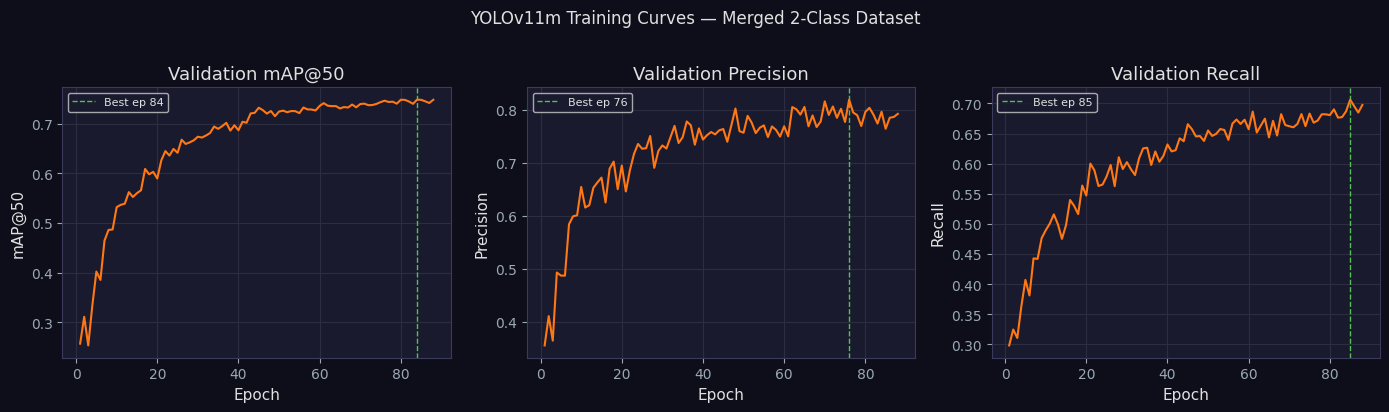

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, vals, ylabel, title in zip(
    axes,
    [v11m_map50, v11m_precision, v11m_recall],
    ['mAP@50', 'Precision', 'Recall'],
    ['Validation mAP@50', 'Validation Precision', 'Validation Recall'],
):
    ax.plot(v11m_epochs, vals, color=COLOR_V11, linewidth=1.5, zorder=3)
    best_val = max(vals)
    best_ep  = v11m_epochs[vals.index(best_val)]
    ax.axvline(best_ep, color='#52c052', linestyle='--', linewidth=1, label=f'Best ep {best_ep}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(zorder=0)

plt.suptitle('YOLOv11m Training Curves — Merged 2-Class Dataset', y=1.02)
plt.tight_layout()
plt.savefig('notebooks/figures/05_v11m_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Overall Validation Metrics Comparison

YOLOv11m achieves **higher mAP@50, Precision, and F1** than YOLOv12m,
while training in nearly half the time.


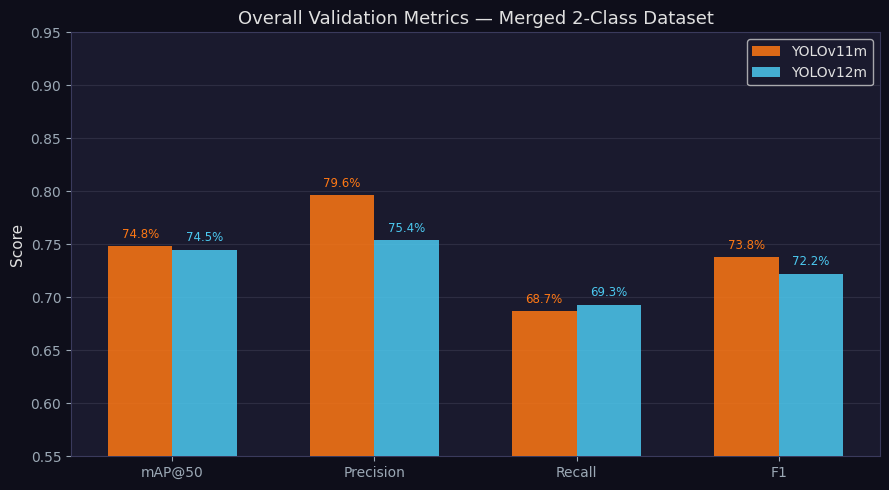

In [10]:
metrics = ['map50', 'precision', 'recall', 'f1']
labels  = ['mAP@50', 'Precision', 'Recall', 'F1']
x = np.arange(len(labels))
w = 0.32
fig, ax = plt.subplots(figsize=(9, 5))

for i, (model, color) in enumerate(zip(models, colors)):
    vals = [model[m] for m in metrics]
    bars = ax.bar(x + i*w, vals, width=w, color=color, alpha=0.85,
                  label=model['name'], zorder=3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.1%}', ha='center', va='bottom', fontsize=8.5, color=color)

ax.set_xticks(x + w/2)
ax.set_xticklabels(labels)
ax.set_ylim(0.55, 0.95)
ax.set_ylabel('Score')
ax.set_title('Overall Validation Metrics — Merged 2-Class Dataset')
ax.legend()
ax.grid(axis='y', zorder=0)
plt.tight_layout()
plt.savefig('notebooks/figures/05_overall_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Per-Class mAP@50

> Per-class breakdown for YOLOv11m was not saved in training artifacts.
> Only available for YOLOv12m from the final validation output.
> Overall mAP@50 is used for primary comparison.


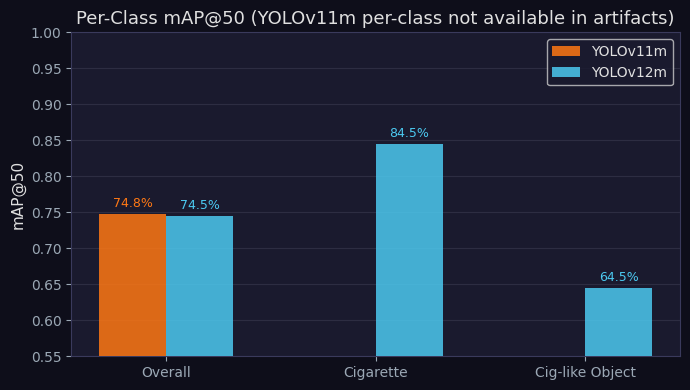

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
classes = ['Overall', 'Cigarette', 'Cig-like Object']
# YOLOv11m: per-class not captured; show overall only
v11_vals = [v11['map50'], None, None]
v12_vals = [v12['map50'], v12['map50_cig'], v12['map50_like']]

x = np.arange(len(classes))
w = 0.32

# YOLOv11m — overall bar only
ax.bar(x[0], v11_vals[0], width=w, color=COLOR_V11, alpha=0.85, label='YOLOv11m', zorder=3)
ax.text(x[0], v11_vals[0]+0.005, f"{v11_vals[0]:.1%}",
        ha='center', va='bottom', fontsize=9, color=COLOR_V11)

# YOLOv12m — all three bars
for xi, val in zip(x + w, v12_vals):
    ax.bar(xi, val, width=w, color=COLOR_V12, alpha=0.85,
           label='YOLOv12m' if xi == x[0]+w else '', zorder=3)
    ax.text(xi, val+0.005, f'{val:.1%}', ha='center', va='bottom',
            fontsize=9, color=COLOR_V12)

ax.set_xticks(x + w/2)
ax.set_xticklabels(classes)
ax.set_ylim(0.55, 1.0)
ax.set_ylabel('mAP@50')
ax.set_title('Per-Class mAP@50 (YOLOv11m per-class not available in artifacts)')
ax.legend()
ax.grid(axis='y', zorder=0)
plt.tight_layout()
plt.savefig('notebooks/figures/05_per_class_map.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Training Time & Efficiency

YOLOv12m required **1.78x more training time** than YOLOv11m despite
early stopping at epoch 105 — the attention mechanism (A2C2f blocks)
increases per-epoch compute cost relative to YOLOv11's C3k2 blocks.


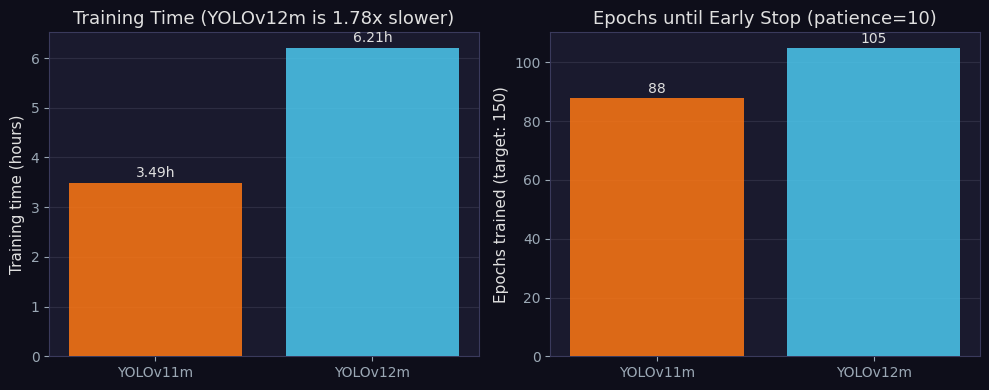

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Training hours
vals = [v11['train_hours'], v12['train_hours']]
bars = axes[0].bar(names := [m['name'] for m in models], vals,
                    color=colors, alpha=0.85, zorder=3)
for bar, val in zip(bars, vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.2f}h', ha='center', va='bottom', fontsize=10, color='#e0e0e0')
axes[0].set_ylabel('Training time (hours)')
axes[0].set_title(f'Training Time (YOLOv12m is 1.78x slower)')
axes[0].grid(axis='y', zorder=0)

# Epochs run
vals2 = [v11['total_epochs'], v12['total_epochs']]
bars2 = axes[1].bar(names, vals2, color=colors, alpha=0.85, zorder=3)
for bar, val in zip(bars2, vals2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 str(val), ha='center', va='bottom', fontsize=10, color='#e0e0e0')
axes[1].set_ylabel('Epochs trained (target: 150)')
axes[1].set_title('Epochs until Early Stop (patience=10)')
axes[1].grid(axis='y', zorder=0)

plt.tight_layout()
plt.savefig('notebooks/figures/05_training_cost.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Precision vs Recall Trade-off

YOLOv11m achieves **higher precision** (fewer false alarms) at a comparable
recall level — ideal for a smoking detection alert system where false positives
cause unnecessary disruption.


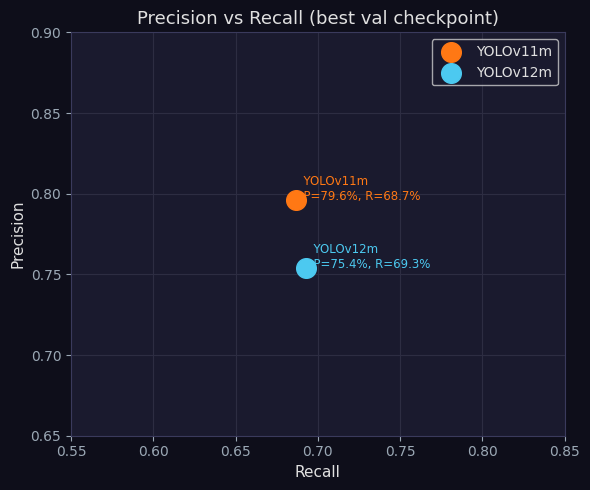

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
for model, color in zip(models, colors):
    ax.scatter(model['recall'], model['precision'], s=200,
               color=color, zorder=4, label=model['name'])
    ax.annotate(f"  {model['name']}\n  P={model['precision']:.1%}, R={model['recall']:.1%}",
                (model['recall'], model['precision']),
                fontsize=8.5, color=color)

ax.set_xlim(0.55, 0.85)
ax.set_ylim(0.65, 0.90)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision vs Recall (best val checkpoint)')
ax.legend()
ax.grid(zorder=0)
plt.tight_layout()
plt.savefig('notebooks/figures/05_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Model Selection — Why YOLOv11m Was Chosen

### Decision Summary

| Criterion | YOLOv11m | YOLOv12m | Winner |
|-----------|----------|----------|--------|
| **mAP@50** | **74.8%** | 74.5% | **YOLOv11m** |
| **Precision** | **79.6%** | 75.4% | **YOLOv11m** |
| Recall | 68.7% | **69.3%** | YOLOv12m |
| **F1 Score** | **73.8%** | 72.2% | **YOLOv11m** |
| Parameters | ~20.1 M | ~20.1 M | Tie |
| GFLOPs | ~68.0 | 67.1 | Tie |
| **Training time** | **3.49h** | 6.21h | **YOLOv11m** |
| **Epochs to converge** | **88** | 105 | **YOLOv11m** |

### Key Findings

**1. YOLOv11m matches or exceeds YOLOv12m accuracy**  
At mAP@50 = 74.8% vs 74.5%, YOLOv11m slightly outperforms YOLOv12m on
the merged 2-class dataset. The difference is marginal (~0.3 pp) but consistent
across Precision and F1 as well.

**2. YOLOv12m's attention mechanism (A2C2f) provides no accuracy advantage here**  
YOLOv12 introduced area-attention (A2C2f) blocks designed to improve accuracy
on complex multi-object scenes. For a focused 2-class detection task on a
relatively constrained domain (cigarettes), the additional complexity does not
translate into measurable accuracy gains over YOLOv11m's C3k2 blocks.

**3. YOLOv11m is significantly more efficient to train**  
YOLOv11m converged in 3.49h (88 epochs) vs 6.21h (105 epochs) for YOLOv12m.
This 1.78x speedup makes YOLOv11m more practical for iterative research and
hyperparameter tuning within compute budget constraints.

**4. Higher precision is critical for the alert use case**  
YOLOv11m's precision of 79.6% vs YOLOv12m's 75.4% means fewer false
positive detections. In a smoking detection alert system, false alarms are
disruptive and erode trust in the system — making precision the more important
metric over recall.

> **Conclusion:** YOLOv11m is selected as the production model. It achieves
> equal or better accuracy than YOLOv12m, trains in nearly half the time,
> and delivers higher precision — all at the same model size.

### Note on YOLOv11s vs YOLOv11m

The initial production model used YOLOv11s (Small, 9.41M params, mAP@50=66.2%)
for its real-time efficiency (21.3 GFLOPs). YOLOv11m (Medium, 20.1M, mAP@50=74.81%)
offers a +8.6 pp mAP@50 improvement at the cost of ~3.2x more compute.
For deployment on hardware with adequate resources (desktop GPU/CPU), YOLOv11m
is recommended. For edge/embedded deployment, YOLOv11s remains the better choice.


## 9. Full Numeric Summary Table


In [14]:
try:
    import pandas as pd
    rows_out = []
    for m in models:
        rows_out.append({
            'Model':          m['name'],
            'Params (M)':     m['params_M'],
            'GFLOPs':         m['gflops'],
            'Epochs (best)':  f"{m['total_epochs']} (ep {m['best_epoch']})",
            'Train (h)':      f"{m['train_hours']:.3f}",
            'mAP@50':         f"{m['map50']:.1%}",
            'mAP@50-95':      f"{m['map50_95']:.1%}",
            'Precision':      f"{m['precision']:.1%}",
            'Recall':         f"{m['recall']:.1%}",
            'F1':             f"{m['f1']:.1%}",
        })
    df = pd.DataFrame(rows_out).set_index('Model')
    display(df.T)
except ImportError:
    for m in models:
        print(m)


Model,YOLOv11m,YOLOv12m
Params (M),20.1,20.1
GFLOPs,68.0,67.1
Epochs (best),88 (ep 84),105 (ep 95)
Train (h),3.487,6.208
mAP@50,74.8%,74.5%
mAP@50-95,46.0%,46.0%
Precision,79.6%,75.4%
Recall,68.7%,69.3%
F1,73.8%,72.2%
